# Changepoint injection

A changepoint is a *structural break*: the series switches to a new level, trend, or variance and stays there. Unlike an anomaly, which is a transient outlier, a changepoint is a genuine regime change — exactly what breaks models that assume the past looks like the future. Injecting them lets you test whether a forecaster adapts, and gives changepoint detectors a labelled benchmark.

::: {.callout-tip}
## Types and placement

`changepoint_type` selects what breaks — `"level"`, `"trend"`, `"variance"`, or `"mixed"`. Set `changepoint_locations` (fractions of the series) and the matching `changepoint_*_changes` to place breaks exactly, or give only `num_changepoints` to scatter them randomly. `exogenous=ExogenousConfig(changepoint_flags=True)` adds a `changepoint_flag` column marking each break — drawn as dashed vertical lines below.
:::

In [ ]:
import matplotlib.pyplot as plt
import polars as pl

from synforecast.exogenous import ExogenousConfig
from synforecast.generators import RandomWalkGenerator, SeasonalGenerator, VARGenerator

FLAGS = ExogenousConfig(changepoint_flags=True)


def plot_changepoints(df, title):
    """Plot each series and mark changepoints (changepoint_flag == 1) as vlines."""
    fig, ax = plt.subplots(figsize=(11, 4))
    for uid in df["unique_id"].unique(maintain_order=True).to_list():
        s = df.filter(pl.col("unique_id") == uid).sort("ds")
        ax.plot(s["ds"], s["y"], linewidth=1, alpha=0.85, label=str(uid))
        for ts in s.filter(pl.col("changepoint_flag") == 1)["ds"].to_list():
            ax.axvline(ts, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
    ax.set(title=title, xlabel="ds", ylabel="y")
    if df["unique_id"].n_unique() > 1:
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## Level breaks

The most common structural break: the series jumps to a new baseline. Here three breaks at 20%, 50%, and 80% of the series, with explicit jump sizes.

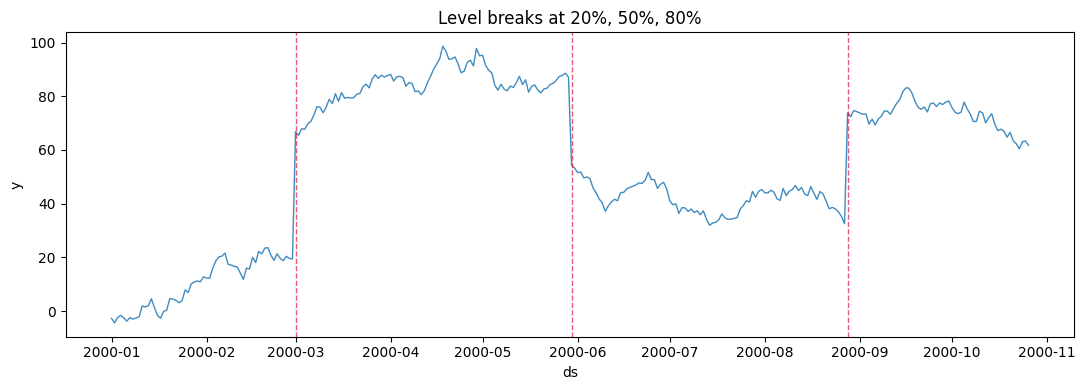

In [ ]:
level_df = RandomWalkGenerator(
    engine="polars",
    min_length=300,
    max_length=300,
    freq="D",
    drift=0.1,
    volatility=2.0,
    changepoints=True,
    num_changepoints=3,
    changepoint_type="level",
    changepoint_level_changes=[50.0, -30.0, 40.0],
    changepoint_locations=[0.2, 0.5, 0.8],
    exogenous=FLAGS,
    seed=42,
).generate(n_series=1)
plot_changepoints(level_df, "Level breaks at 20%, 50%, 80%")

At each dashed line the series steps to a new level and continues from there — the jump sizes are exactly the `changepoint_level_changes` you passed.

## Trend breaks

A trend break changes the *slope* rather than the level, so the series bends at each changepoint. This example adds them on top of a weekly-seasonal series.

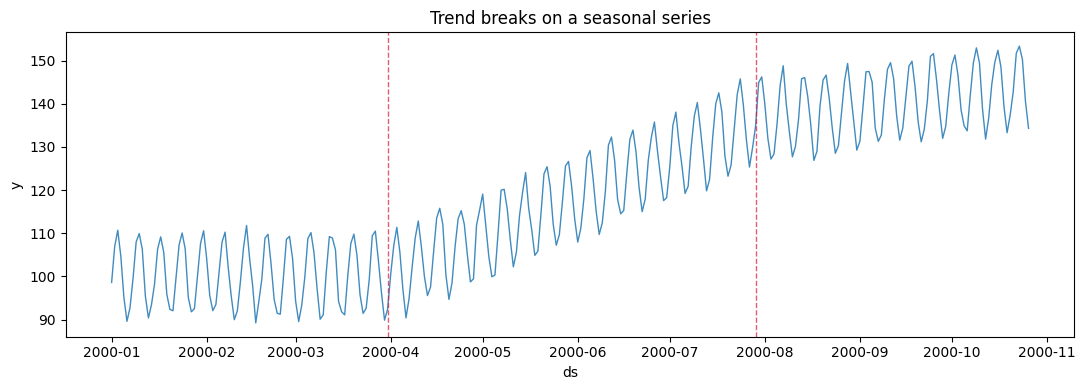

In [ ]:
trend_df = SeasonalGenerator(
    engine="polars",
    min_length=300,
    max_length=300,
    freq="D",
    seasonality_period=7,
    seasonality_amplitude=10.0,
    base_level=100.0,
    changepoints=True,
    num_changepoints=2,
    changepoint_type="trend",
    changepoint_trend_changes=[0.3, -0.2],
    changepoint_locations=[0.3, 0.7],
    exogenous=FLAGS,
    seed=42,
).generate(n_series=1)
plot_changepoints(trend_df, "Trend breaks on a seasonal series")

## Variance breaks

A variance break changes the *noise amplitude* — the level and trend are unchanged, but the series becomes calmer or more volatile. These matter for prediction intervals, which should widen after a jump in variance.

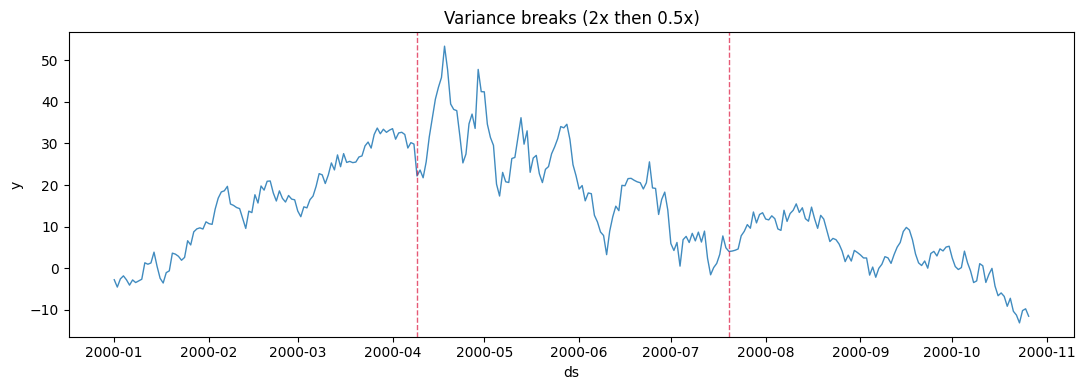

In [ ]:
variance_df = RandomWalkGenerator(
    engine="polars",
    min_length=300,
    max_length=300,
    freq="D",
    drift=0.05,
    volatility=2.0,
    changepoints=True,
    num_changepoints=2,
    changepoint_type="variance",
    changepoint_variance_changes=[2.0, 0.5],
    changepoint_locations=[0.33, 0.67],
    exogenous=FLAGS,
    seed=42,
).generate(n_series=1)
plot_changepoints(variance_df, "Variance breaks (2x then 0.5x)")

## Mixed types and automatic placement

Use `changepoint_type="mixed"` to draw a different kind of break at each changepoint, and omit `changepoint_locations` to scatter them at random positions — closer to how breaks arrive in real data.

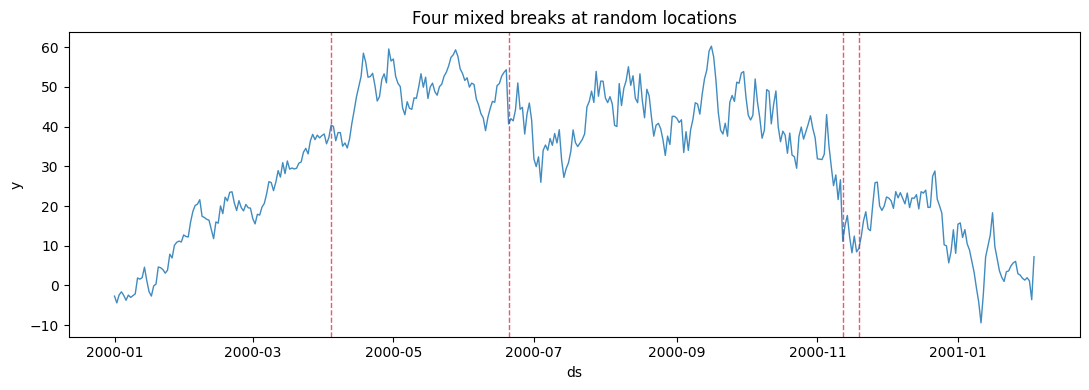

In [ ]:
mixed_df = RandomWalkGenerator(
    engine="polars",
    min_length=400,
    max_length=400,
    freq="D",
    drift=0.1,
    volatility=2.0,
    changepoints=True,
    num_changepoints=4,
    changepoint_type="mixed",
    exogenous=FLAGS,
    seed=42,
).generate(n_series=1)
plot_changepoints(mixed_df, "Four mixed breaks at random locations")

## Multivariate and composed

Like all pipeline features, changepoints apply to multivariate generators, and compose with anomalies and missing data for a realistically hard series.

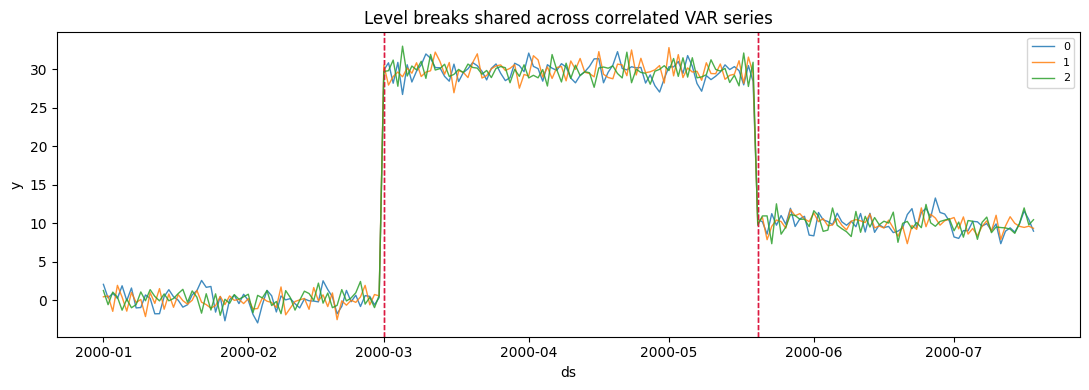

In [ ]:
var_df = VARGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    lag_order=1,
    changepoints=True,
    num_changepoints=2,
    changepoint_type="level",
    changepoint_level_changes=[30.0, -20.0],
    changepoint_locations=[0.3, 0.7],
    exogenous=FLAGS,
    seed=42,
).generate(n_series=3)
plot_changepoints(var_df, "Level breaks shared across correlated VAR series")

missing values: 0 of 400


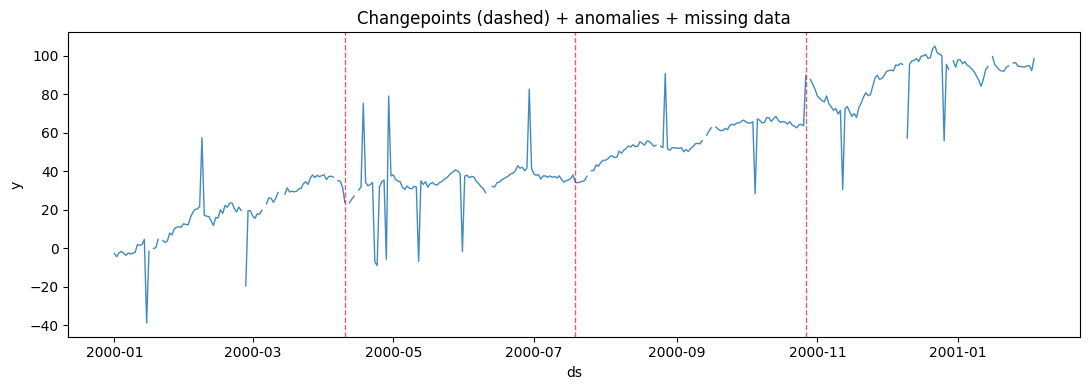

In [ ]:
composed_df = RandomWalkGenerator(
    engine="polars",
    min_length=400,
    max_length=400,
    freq="D",
    drift=0.1,
    volatility=2.0,
    changepoints=True,
    num_changepoints=3,
    changepoint_type="mixed",
    changepoint_locations=[0.25, 0.5, 0.75],
    anomalies=True,
    anomaly_fraction=0.04,
    anomaly_types=["spike", "dip"],
    spike_magnitude=40.0,
    dip_magnitude=-40.0,
    missing_data=True,
    missing_pattern="random",
    missing_rate=0.05,
    exogenous=FLAGS,
    seed=42,
).generate(n_series=1)
print(f"missing values: {composed_df['y'].null_count()} of {len(composed_df)}")
plot_changepoints(composed_df, "Changepoints (dashed) + anomalies + missing data")

::: {.callout-note}
## Related capabilities

- [Anomalies](anomalies) — transient outliers, as opposed to the sustained regime changes here.
- [Missingness](missingness) — random, block, and seasonal gap patterns.
- All changepoint parameters are documented in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::